In [1]:
from pathlib import Path
import scanpy as sc

file_path = Path.home() / "projects" / "multiome-integration-scRNA-scATAC" / "data" / "processed" / "rna_qc_filtered.h5ad"

rna_filt = sc.read_h5ad(file_path)

In [2]:
rna_filt

AnnData object with n_obs × n_vars = 9438 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt'

In [3]:
rna_filt.layers["counts"] = rna_filt.X.copy()

In [4]:
sc.pp.normalize_total(rna_filt, target_sum=1e4) #compare between cells
sc.pp.log1p(rna_filt)

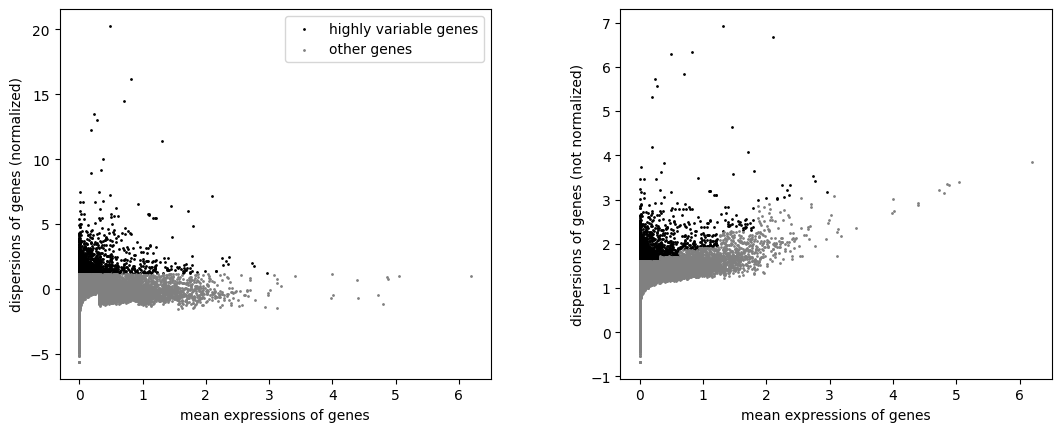

In [5]:
sc.pp.highly_variable_genes(rna_filt, n_top_genes=2000)
sc.pl.highly_variable_genes(rna_filt)

In [6]:
rna_filt = rna_filt[:, rna_filt.var.highly_variable].copy()
print(rna_filt)

AnnData object with n_obs × n_vars = 9438 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'


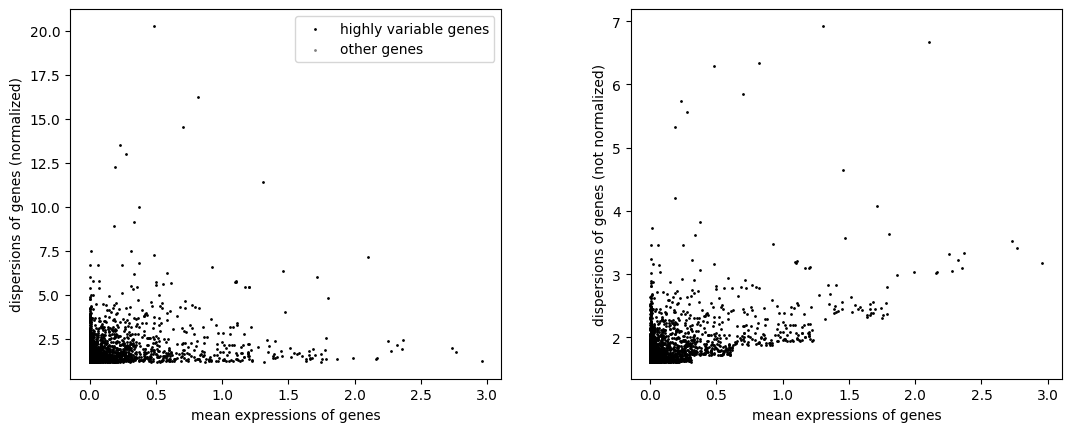

In [7]:
sc.pl.highly_variable_genes(rna_filt)

In [8]:
sc.pp.scale(rna_filt) #standardization (compare between genes)
sc.tl.pca(rna_filt)

/Users/dayejung/conda/envs/multiome-RNA-ATAC/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


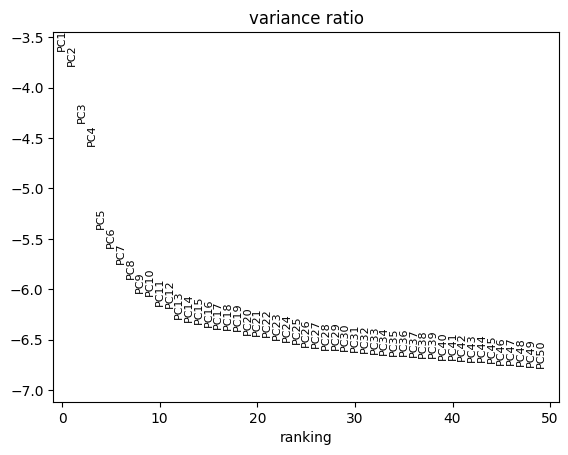

In [9]:
sc.pl.pca_variance_ratio(rna_filt, n_pcs=50, log=True)

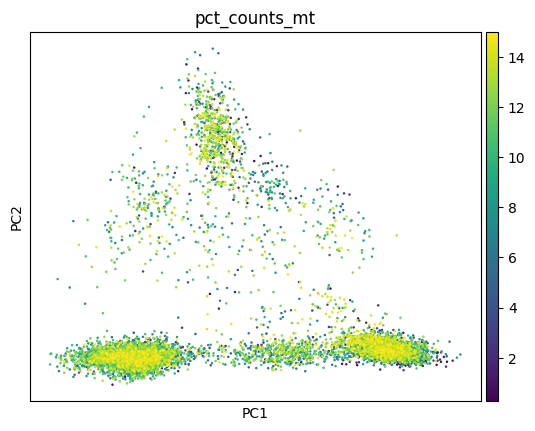

In [10]:
sc.pl.pca(
    rna_filt,
    color=["pct_counts_mt"],
)

In [11]:
sc.pp.neighbors(rna_filt)

/Users/dayejung/conda/envs/multiome-RNA-ATAC/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
sc.tl.umap(rna_filt)

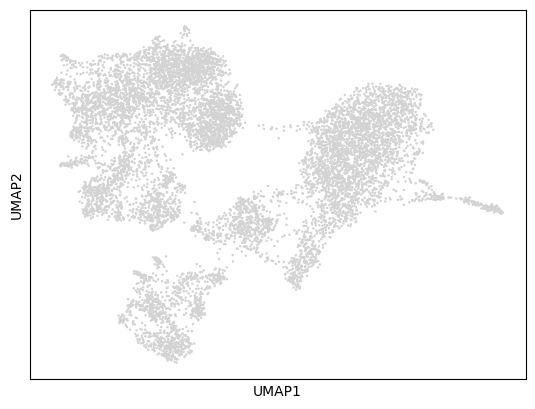

In [13]:
sc.pl.umap(rna_filt)

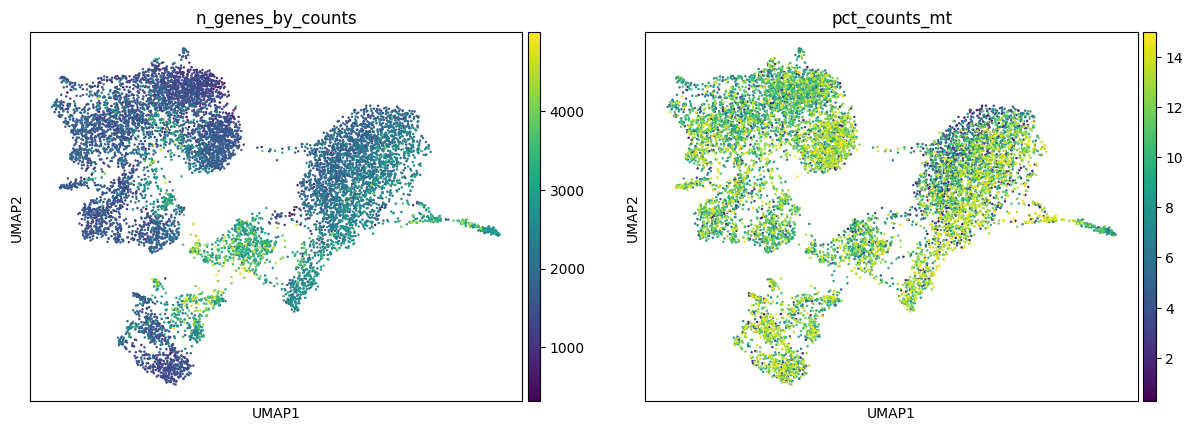

In [14]:
sc.pl.umap(rna_filt, color=["n_genes_by_counts", "pct_counts_mt"])

In [15]:
#Leiden Clustering

sc.tl.leiden(rna_filt, flavor="igraph", n_iterations=2)

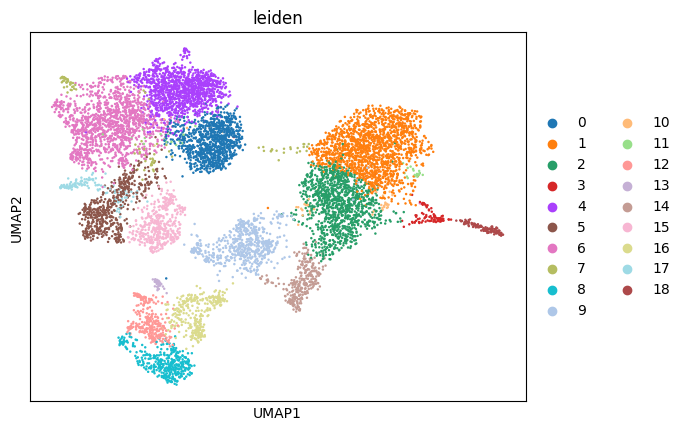

In [16]:
sc.pl.umap(rna_filt, color=["leiden"])

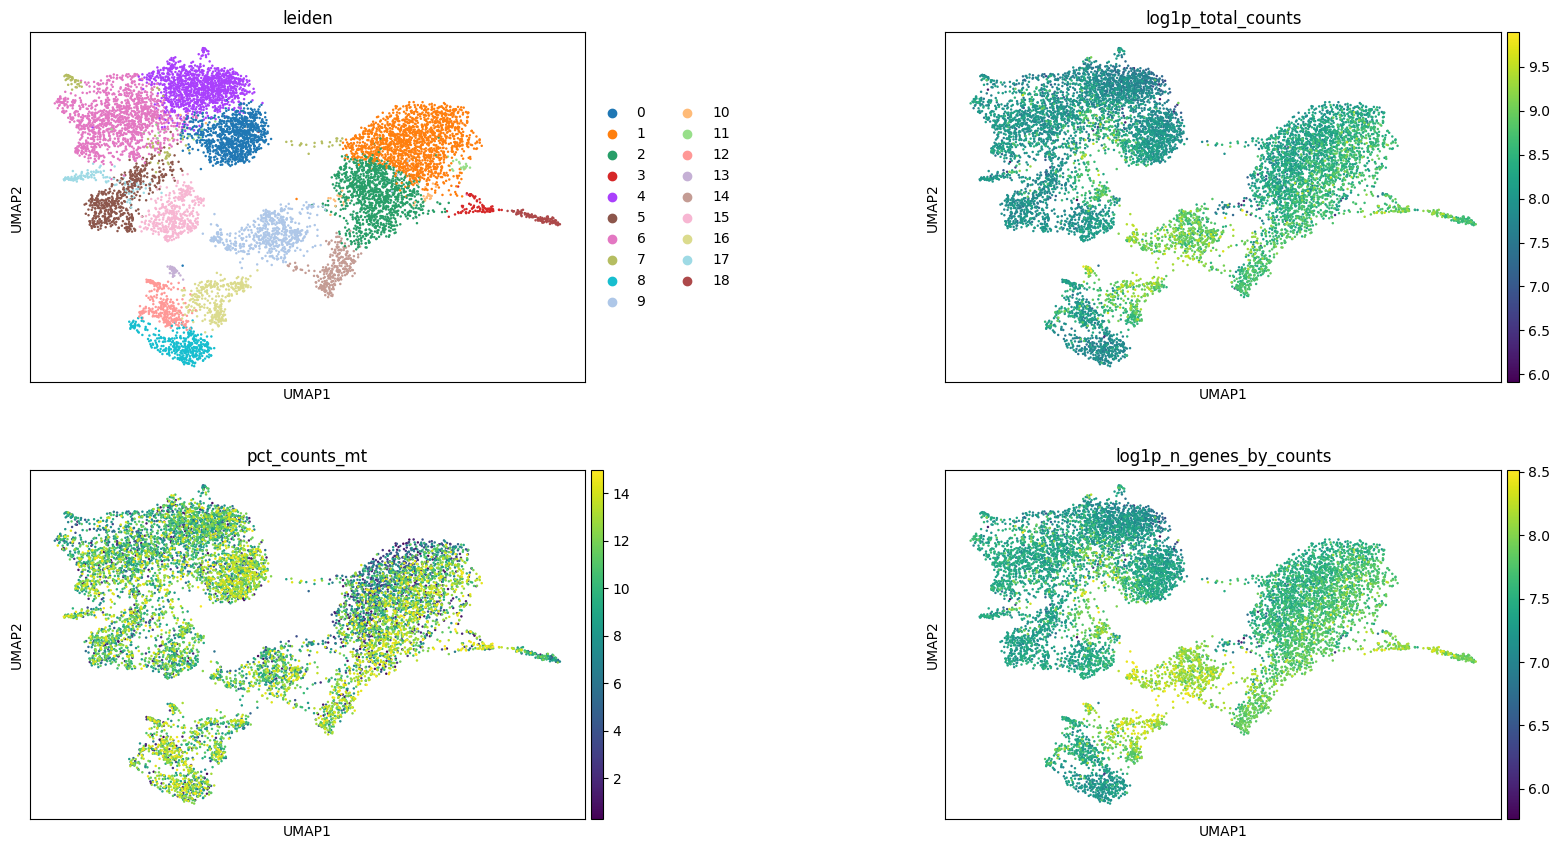

In [19]:
sc.pl.umap(
    rna_filt,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

/Users/dayejung/conda/envs/multiome-RNA-ATAC/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/dayejung/conda/envs/multiome-RNA-ATAC/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/dayejung/conda/envs/multiome-RNA-ATAC/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/dayejung/conda/envs/multiome-RNA-ATAC/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/dayejung/conda/envs/multiome-RNA-ATAC/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning

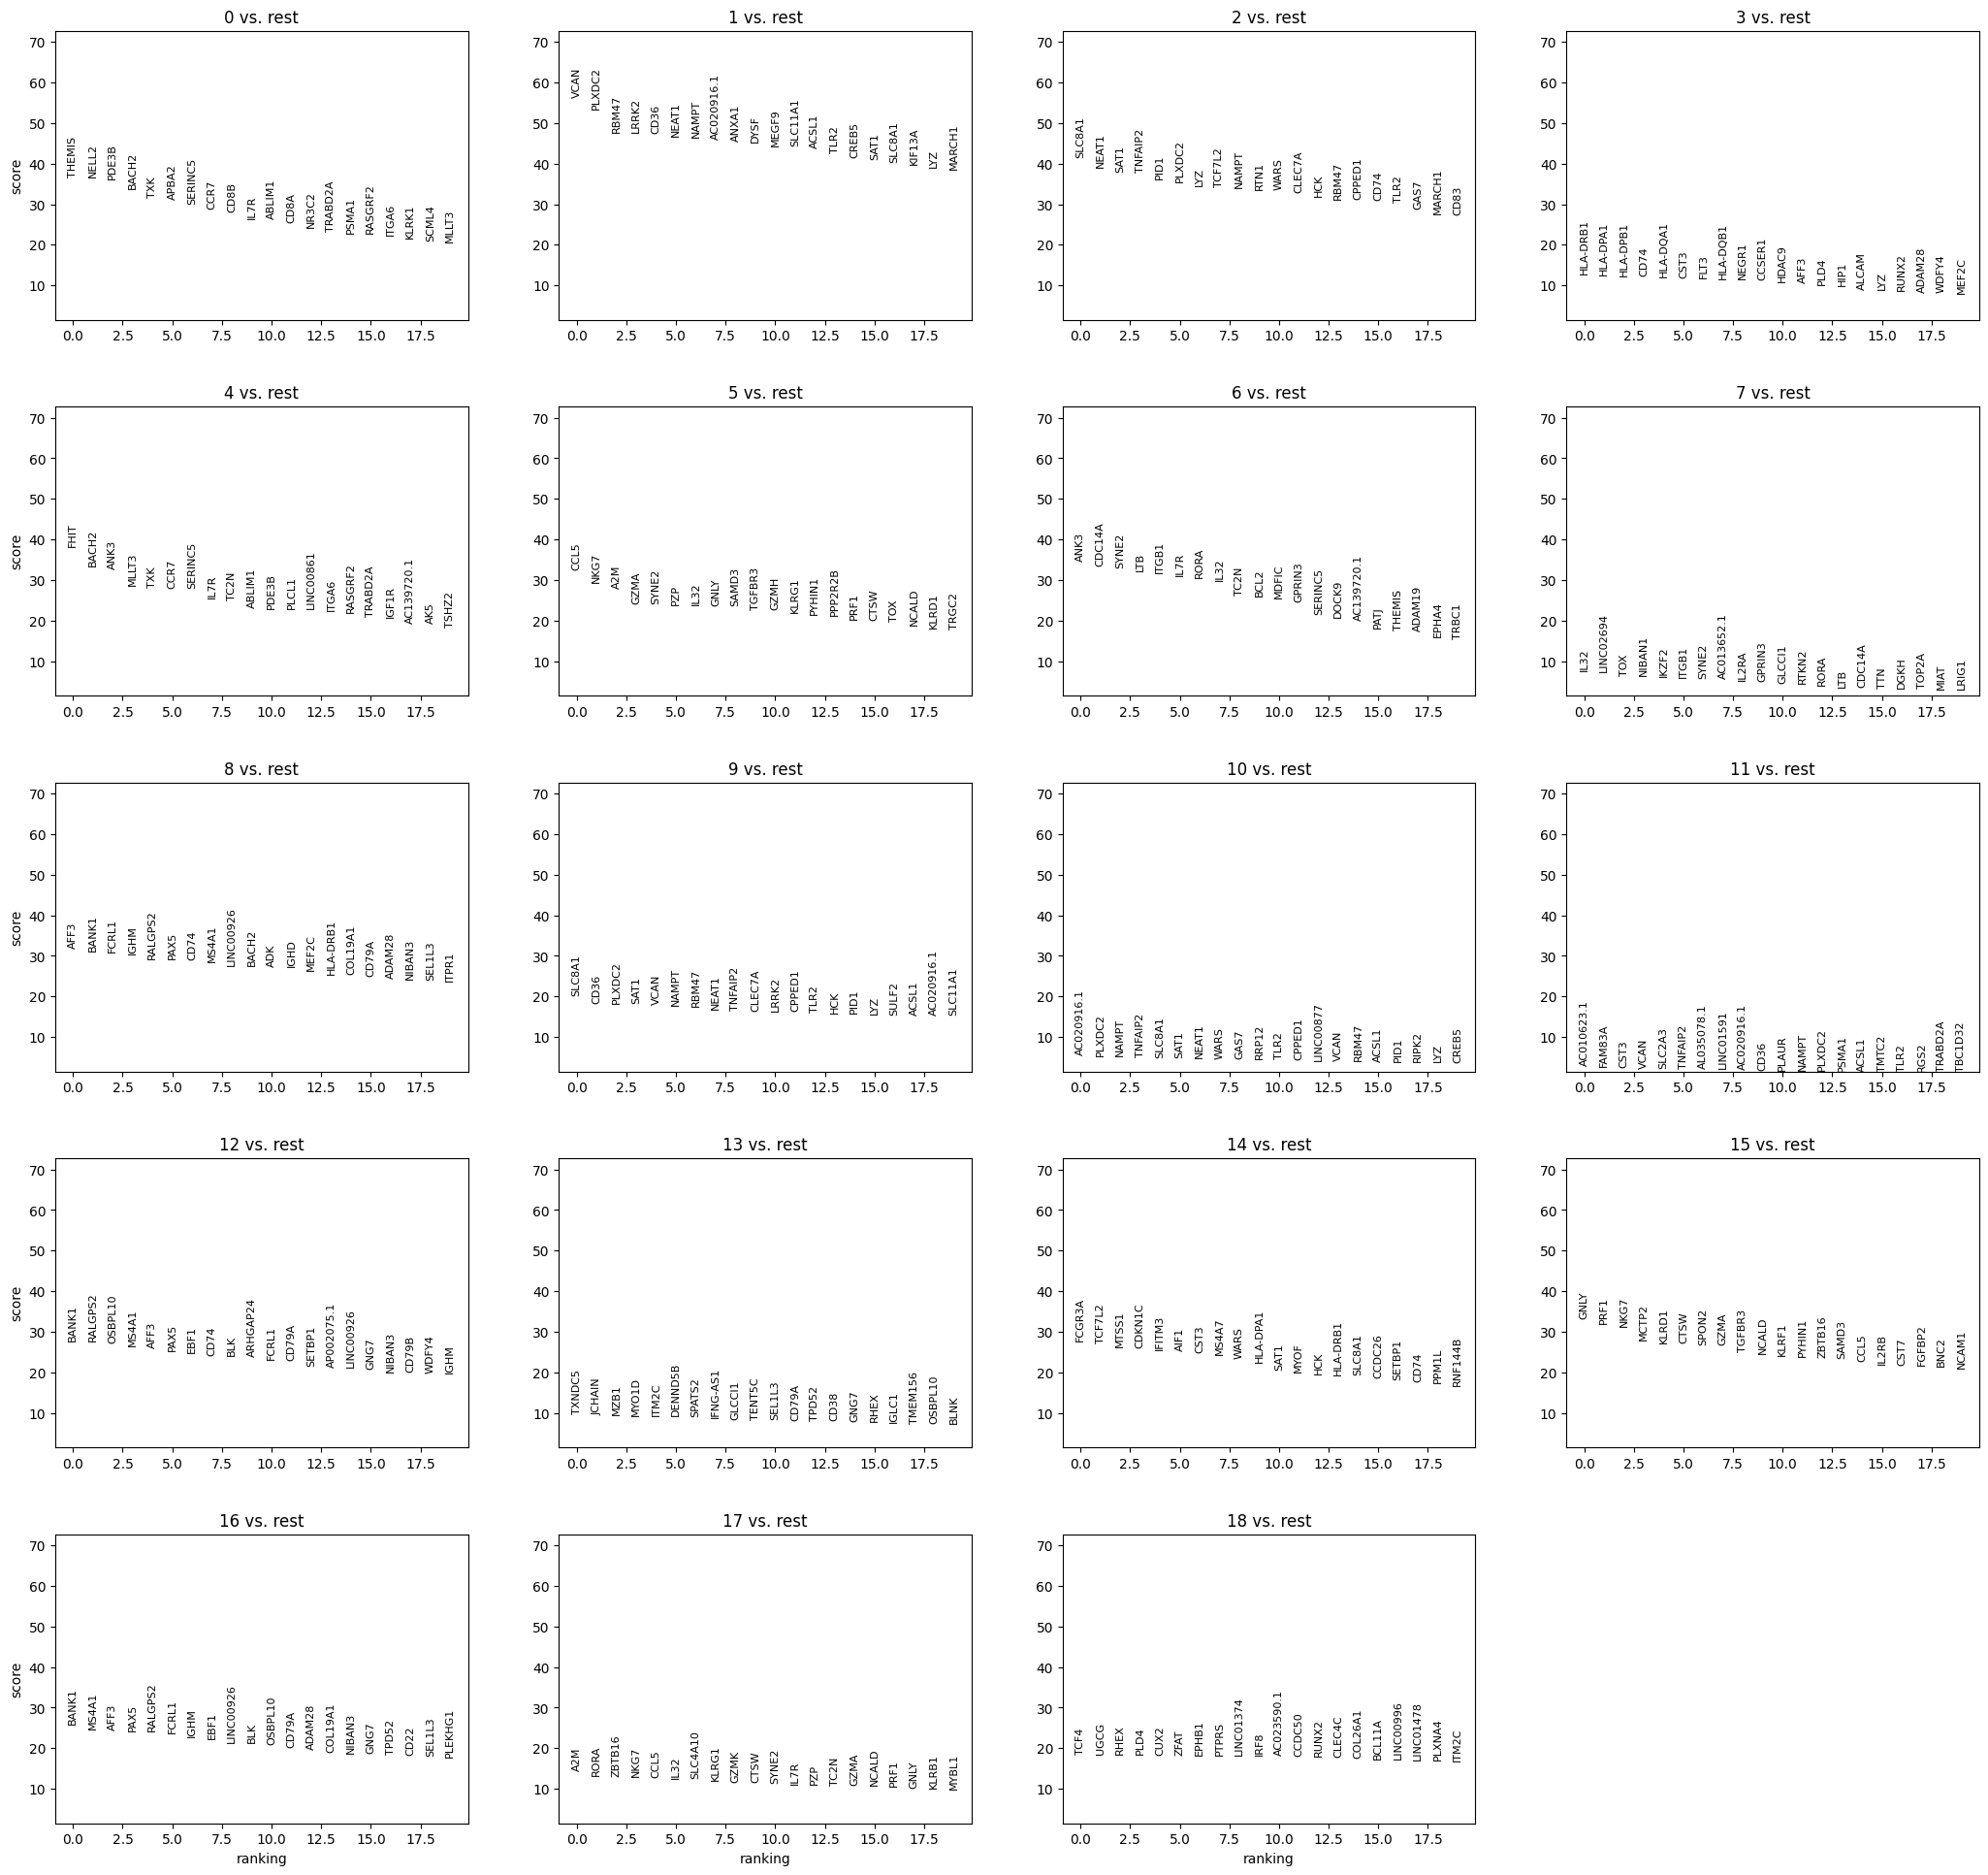

In [20]:
sc.tl.rank_genes_groups(rna_filt, "leiden", method="wilcoxon")
sc.pl.rank_genes_groups(rna_filt, n_genes=20)